# NEBULA pilot PMF analysis

A reproducible first-pass analysis of NEBULA search and feedback events. The default input is a clearly labelled sample fixture; replace it with an export from `/v1/research/export?format=csv` before making research claims.

## tl;dr

This notebook measures search volume, zero-result rate, latency, ranking-mode usage, session coverage, usefulness feedback, and task completion. It is an analysis template until a real pilot export is supplied.

## Context & Methods

The unit of analysis is an event persisted by NEBULA. Search events measure retrieval behavior; feedback events measure a user's judgement of a result. Session IDs are anonymous browser-local identifiers.

### Key Assumptions

- A zero-result search is a retrieval failure signal, not proof that the corpus lacks the answer.
- Useful feedback is descriptive pilot evidence, not a product-market-fit estimate by itself.
- Latency is recorded by the API in nanoseconds and reported here in milliseconds.
- The sample fixture is synthetic and must not be included in university findings.

## Data

### 1. Load and validate the export

In [1]:
from collections import Counter
import csv
from pathlib import Path
from statistics import mean, median

repo_root = Path.cwd()
if not (repo_root / 'data').exists():
    repo_root = repo_root.parent
real_export = repo_root / 'data/nebula-research.csv'
sample_export = repo_root / 'data/nebula-research.sample.csv'
INPUT_PATH = real_export if real_export.exists() else sample_export

required_columns = {'type', 'sessionId', 'timestamp', 'query', 'mode', 'results', 'latencyNanos', 'documentId', 'sourcePath', 'useful'}
with INPUT_PATH.open(newline='', encoding='utf-8') as handle:
    reader = csv.DictReader(handle)
    missing = required_columns - set(reader.fieldnames or [])
    if missing:
        raise ValueError(f'Missing columns: {sorted(missing)}')
    events = [{key: (value or '').strip() for key, value in row.items()} for row in reader]

for event in events:
    event['timestamp'] = int(event['timestamp'])
    if event['type'] == 'search':
        event['results'] = int(event['results'])
        event['latencyMs'] = int(event['latencyNanos']) / 1_000_000
    elif event['type'] == 'feedback':
        event['usefulBool'] = event['useful'].lower() == 'true'
    elif event['type'] == 'observation':
        event['confidenceValue'] = int(event['confidence'])

search_events = [event for event in events if event['type'] == 'search']
feedback_events = [event for event in events if event['type'] == 'feedback']
observation_events = [event for event in events if event['type'] == 'observation']
print(f'Input: {INPUT_PATH}')
print(f'Events: {len(events)} | searches: {len(search_events)} | feedback: {len(feedback_events)}')

Input: C:\Users\USER\OneDrive\Desktop\NEBULA\data\nebula-research.sample.csv
Events: 16 | searches: 4 | feedback: 3


## Results

### 2. Compute PMF-oriented measures

In [2]:
search_count = len(search_events)
zero_result_rate = sum(event['results'] == 0 for event in search_events) / search_count if search_count else 0
average_latency_ms = mean(event['latencyMs'] for event in search_events) if search_events else 0
useful_rate = sum(event['usefulBool'] for event in feedback_events) / len(feedback_events) if feedback_events else 0
summary = {
    'searches': search_count,
    'zero_result_rate': round(zero_result_rate, 3),
    'average_latency_ms': round(average_latency_ms, 2),
    'feedback_events': len(feedback_events),
    'useful_rate': round(useful_rate, 3),
    'sessions': len({event['sessionId'] for event in events if event['sessionId']}),
}
mode_counts = Counter(event['mode'] for event in search_events)
summary, dict(mode_counts)

({'searches': 4,
  'zero_result_rate': 0.25,
  'average_latency_ms': 19.25,
  'feedback_events': 3,
  'useful_rate': 0.667,
  'sessions': 2},
 {'bm25': 2, 'hybrid': 1, 'semantic': 1})

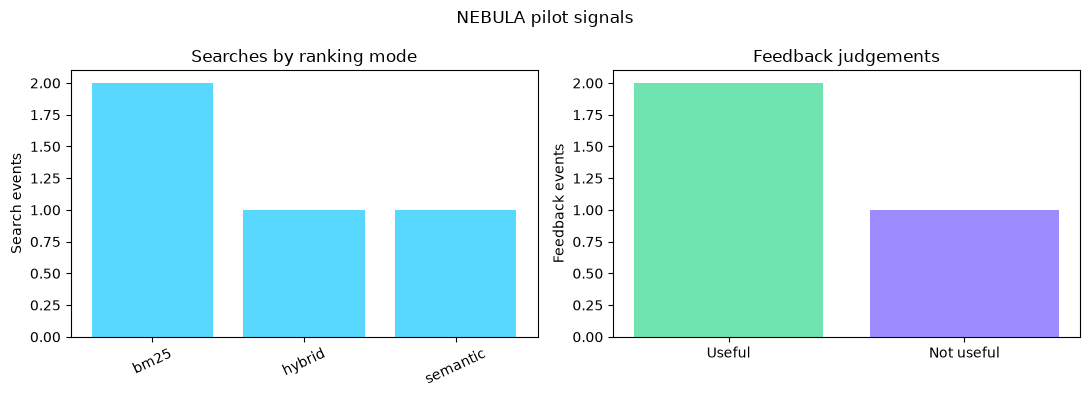

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(list(mode_counts.keys()) or ['none'], list(mode_counts.values()) or [0], color='#59d8ff')
axes[0].set_title('Searches by ranking mode')
axes[0].set_ylabel('Search events')
axes[0].tick_params(axis='x', rotation=25)
axes[1].bar(['Useful', 'Not useful'], [sum(event['usefulBool'] for event in feedback_events), sum(not event['usefulBool'] for event in feedback_events)], color=['#70e4b0', '#9c8cff'])
axes[1].set_title('Feedback judgements')
axes[1].set_ylabel('Feedback events')
fig.suptitle('NEBULA pilot signals')
fig.tight_layout()
plt.show()

### 3. Analyze study-task completion

In [4]:
task_events = [event for event in events if event['type'] == 'task']
task_completions = [event for event in task_events if event['action'] == 'complete']
successful_tasks = [event for event in task_completions if event['success'].lower() == 'true']
task_success_rate = len(successful_tasks) / len(task_completions) if task_completions else 0
task_median_duration_ms = median(int(event['durationMs']) for event in task_completions) if task_completions else 0
task_summary = {
    'task_starts': sum(event['action'] == 'start' for event in task_events),
    'task_completions': len(task_completions),
    'task_success_rate': round(task_success_rate, 3),
    'task_median_duration_ms': task_median_duration_ms,
}
by_task = {task_id: {
    'completions': sum(event['taskId'] == task_id for event in task_completions),
    'success_rate': round(sum(event['taskId'] == task_id and event['success'].lower() == 'true' for event in task_completions) / max(1, sum(event['taskId'] == task_id for event in task_completions)), 3),
    'median_duration_ms': median(int(event['durationMs']) for event in task_completions if event['taskId'] == task_id),
} for task_id in sorted({event['taskId'] for event in task_completions})}
task_summary, by_task

({'task_starts': 3,
  'task_completions': 3,
  'task_success_rate': 0.667,
  'task_median_duration_ms': 55000},
 {'deployment-rollback': {'completions': 1,
   'success_rate': 1.0,
   'median_duration_ms': 45000},
  'retrieval-explanation': {'completions': 1,
   'success_rate': 0.0,
   'median_duration_ms': 55000},
  'shard-failure': {'completions': 1,
   'success_rate': 1.0,
   'median_duration_ms': 60000}})

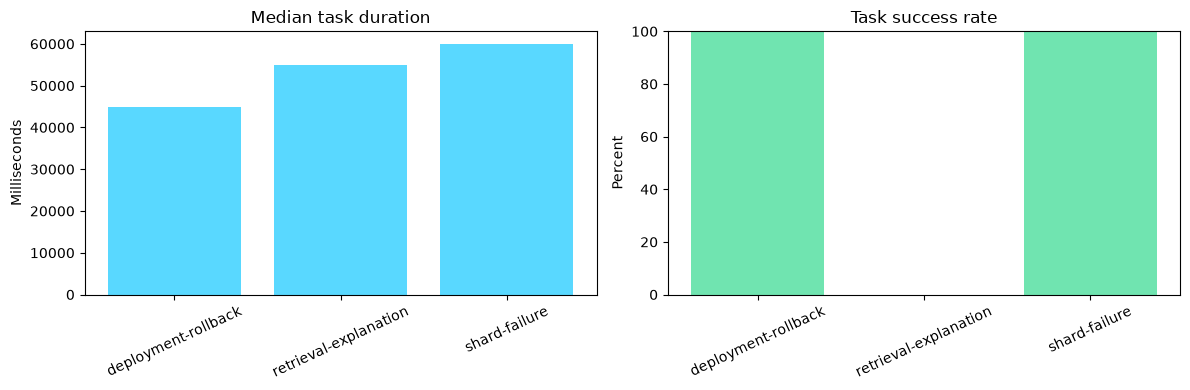

In [5]:
import matplotlib.pyplot as plt

task_labels = list(by_task.keys()) or ['none']
task_durations = [by_task[label]['median_duration_ms'] for label in task_labels] if by_task else [0]
task_success_rates = [by_task[label]['success_rate'] * 100 for label in task_labels] if by_task else [0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(task_labels, task_durations, color='#59d8ff')
axes[0].set_title('Median task duration')
axes[0].set_ylabel('Milliseconds')
axes[0].tick_params(axis='x', rotation=25)
axes[1].bar(task_labels, task_success_rates, color='#70e4b0')
axes[1].set_title('Task success rate')
axes[1].set_ylabel('Percent')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=25)
fig.tight_layout()
plt.show()

### 4. Measure reformulation and time to first useful source

In [6]:
task_starts = {event['taskId']: event['timestamp'] for event in task_events if event['action'] == 'start'}
task_metrics = {}
for task_id, start_timestamp in task_starts.items():
    task_searches = [event for event in search_events if event['taskId'] == task_id and event['timestamp'] >= start_timestamp]
    useful_feedback = [event for event in feedback_events if event['taskId'] == task_id and event['usefulBool'] and event['timestamp'] >= start_timestamp]
    first_useful_timestamp = min((event['timestamp'] for event in useful_feedback), default=None)
    task_metrics[task_id] = {
        'reformulations': max(0, len(task_searches) - 1),
        'time_to_first_useful_ms': None if first_useful_timestamp is None else first_useful_timestamp - start_timestamp,
    }
task_metrics

{'deployment-rollback': {'reformulations': 0,
  'time_to_first_useful_ms': 15000},
 'shard-failure': {'reformulations': 0, 'time_to_first_useful_ms': 15000},
 'retrieval-explanation': {'reformulations': 1,
  'time_to_first_useful_ms': None}}

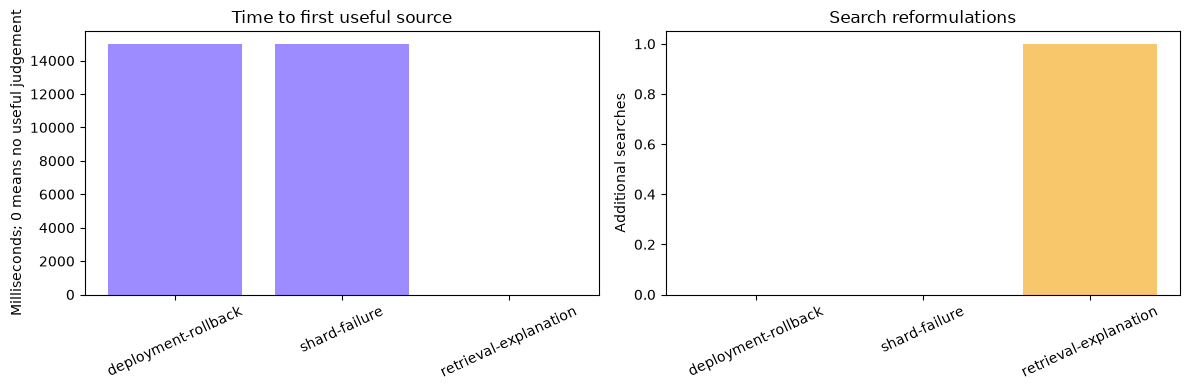

In [7]:
time_labels = list(task_metrics.keys()) or ['none']
time_values = [task_metrics[label]['time_to_first_useful_ms'] or 0 for label in time_labels] if task_metrics else [0]
reformulation_values = [task_metrics[label]['reformulations'] for label in time_labels] if task_metrics else [0]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(time_labels, time_values, color='#9c8cff')
axes[0].set_title('Time to first useful source')
axes[0].set_ylabel('Milliseconds; 0 means no useful judgement')
axes[0].tick_params(axis='x', rotation=25)
axes[1].bar(time_labels, reformulation_values, color='#f8c76b')
axes[1].set_title('Search reformulations')
axes[1].set_ylabel('Additional searches')
axes[1].tick_params(axis='x', rotation=25)
fig.tight_layout()
plt.show()

### 5. Summarize confidence and qualitative observations

In [8]:
confidence_summary = {
    'observation_count': len(observation_events),
    'average_confidence': round(mean(event['confidenceValue'] for event in observation_events), 2) if observation_events else None,
    'confidence_by_task': {task_id: round(mean(event['confidenceValue'] for event in observation_events if event['taskId'] == task_id), 2) for task_id in sorted({event['taskId'] for event in observation_events})},
}
confidence_summary

{'observation_count': 3,
 'average_confidence': 3.67,
 'confidence_by_task': {'deployment-rollback': 4,
  'retrieval-explanation': 2,
  'shard-failure': 5}}

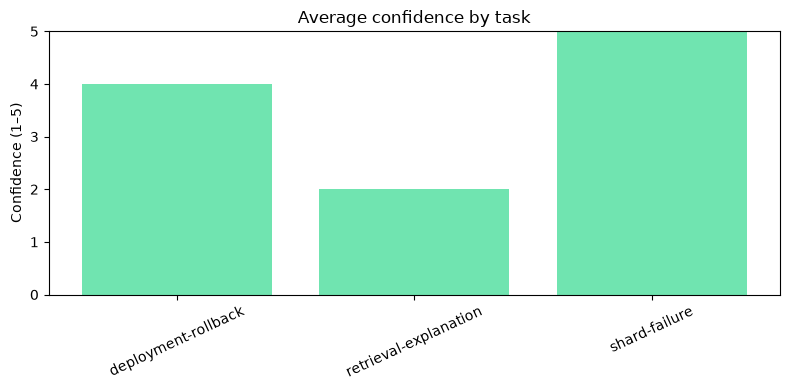

In [9]:
confidence_labels = list(confidence_summary['confidence_by_task'].keys()) or ['none']
confidence_values = list(confidence_summary['confidence_by_task'].values()) or [0]
plt.figure(figsize=(8, 4))
plt.bar(confidence_labels, confidence_values, color='#70e4b0')
plt.title('Average confidence by task')
plt.ylabel('Confidence (1–5)')
plt.ylim(0, 5)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Qualitative notes are intentionally shown as a bounded review list. Before sharing results, redact any participant-identifying or sensitive operational content.

In [10]:
[(event['taskId'], event['note']) for event in observation_events][:10]

[('deployment-rollback', 'clear rollback evidence'),
 ('shard-failure', 'runbook was authoritative'),
 ('retrieval-explanation', 'ranking explanation was unclear')]

## Takeaways

Use the executed `summary` output and charts to write study-specific conclusions after replacing the sample fixture with a real export. Report the corpus version, pilot dates, number of sessions, and task protocol alongside these metrics.

A responsible interpretation should distinguish retrieval quality (zero-result rate and usefulness) from product experience (latency, reformulation behavior, and repeat intent). Small samples should be presented as exploratory evidence with uncertainty, not as proof of product-market fit.